In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features.copy()
y = bank_marketing.data.targets.copy()

# y is usually a DataFrame with one column named "y"
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# convert target yes/no -> 1/0
y = y.map({"yes": 1, "no": 0})

# combine for EDA convenience
df = X.copy()
df["y"] = y

print("Metadata:")
print(bank_marketing.metadata)

print("\nVariables:")
print(bank_marketing.variables)

print("\nShape:", df.shape)
print(df.head())
print(df.info())

Metadata:
{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to pre

In [2]:
neg = (df["balance"] < 0).mean()
zero = (df["balance"] == 0).mean()
pos = (df["balance"] > 0).mean()

print(f"Negative: {neg:.4f} ({neg*100:.2f}%)")
print(f"Zero:     {zero:.4f} ({zero*100:.2f}%)")
print(f"Positive: {pos:.4f} ({pos*100:.2f}%)")

Negative: 0.0833 (8.33%)
Zero:     0.0777 (7.77%)
Positive: 0.8390 (83.90%)


In [3]:
## basic setup
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## EDA


Missing values by column:
poutcome       36959
contact        13020
education       1857
job              288
month              0
previous           0
pdays              0
campaign           0
duration           0
age                0
day_of_week        0
loan               0
housing            0
balance            0
default            0
marital            0
y                  0
dtype: int64

Target counts:
y
0    39922
1     5289
Name: count, dtype: int64

Target proportions:
y
0    0.883015
1    0.116985
Name: proportion, dtype: float64


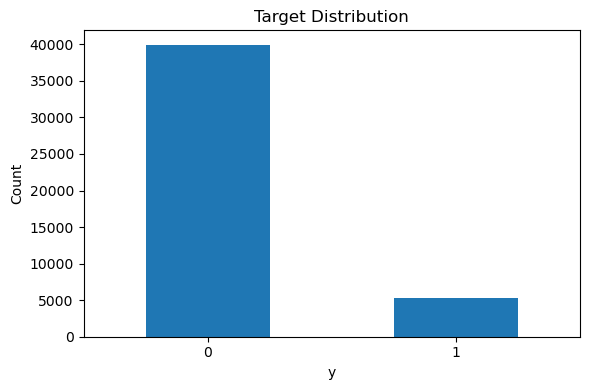


Numeric columns:
['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numeric summary:
               count         mean          std     min    25%    50%     75%  \
age          45211.0    40.936210    10.618762    18.0   33.0   39.0    48.0   
balance      45211.0  1362.272058  3044.765829 -8019.0   72.0  448.0  1428.0   
day_of_week  45211.0    15.806419     8.322476     1.0    8.0   16.0    21.0   
duration     45211.0   258.163080   257.527812     0.0  103.0  180.0   319.0   
campaign     45211.0     2.763841     3.098021     1.0    1.0    2.0     3.0   
pdays        45211.0    40.197828   100.128746    -1.0   -1.0   -1.0    -1.0   
previous     45211.0     0.580323     2.303441     0.0    0.0    0.0     0.0   

                  max  
age              95.0  
balance      102127.0  
day_of_week      31.0  
duration       4918.0  
campaign

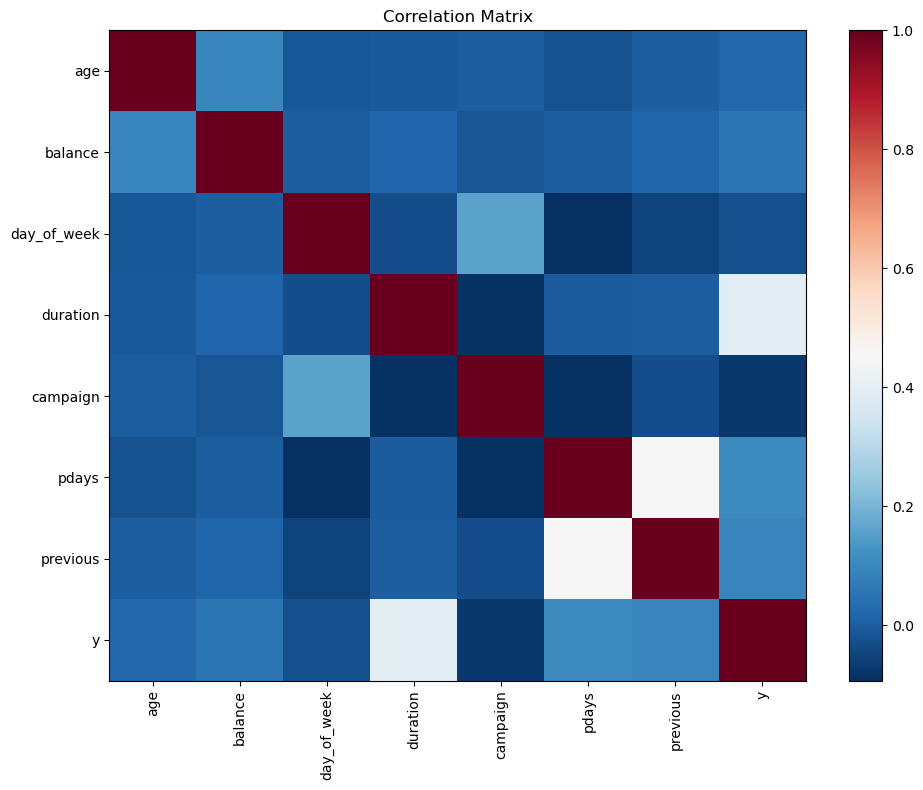

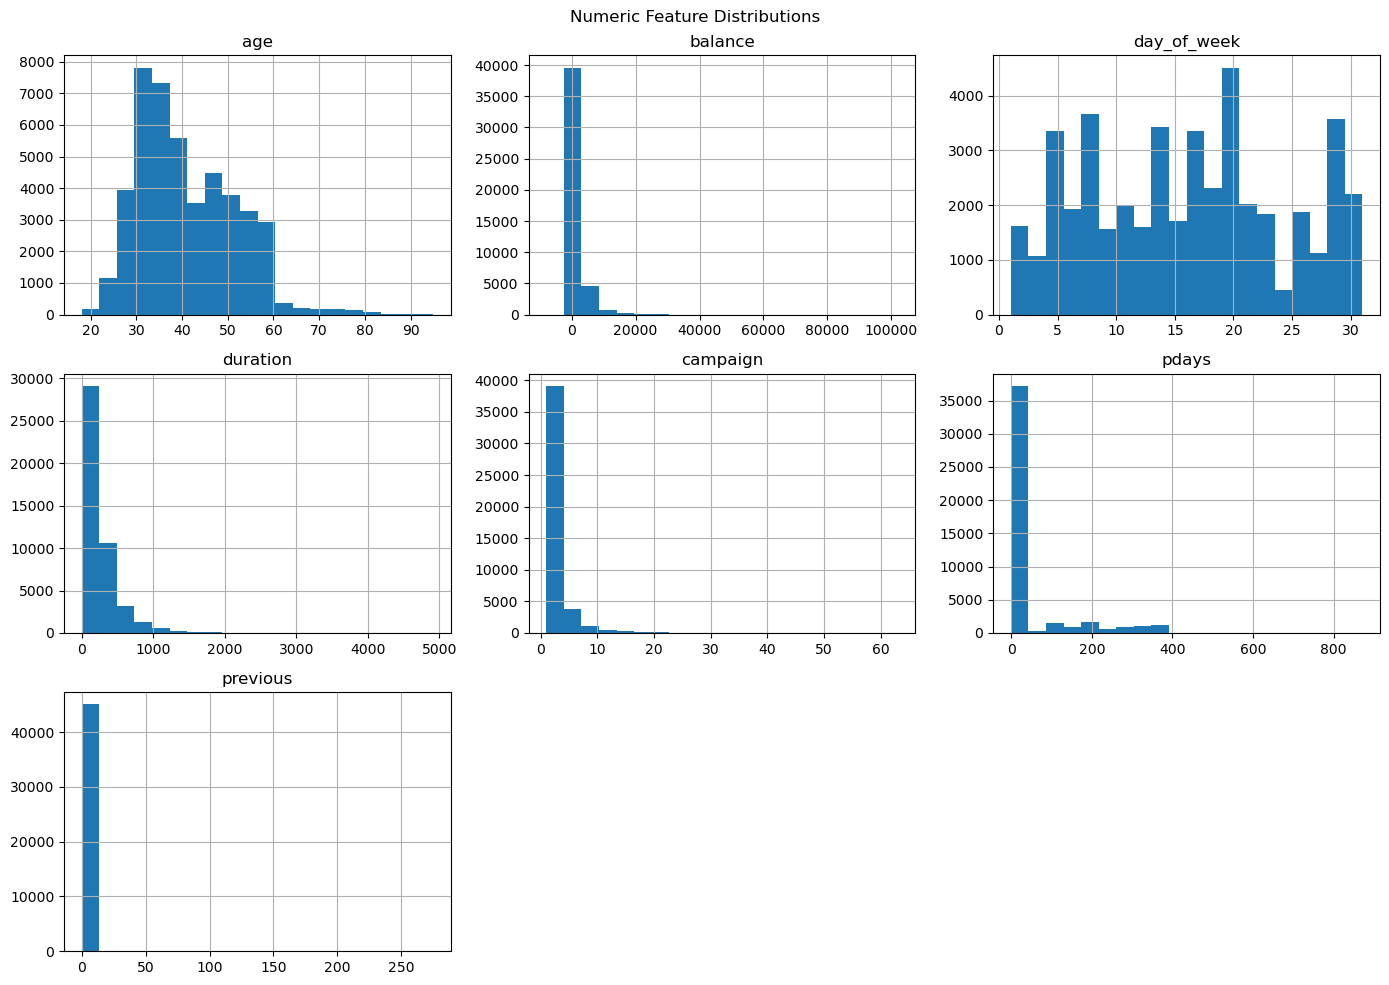


Conversion rate by job:
job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64


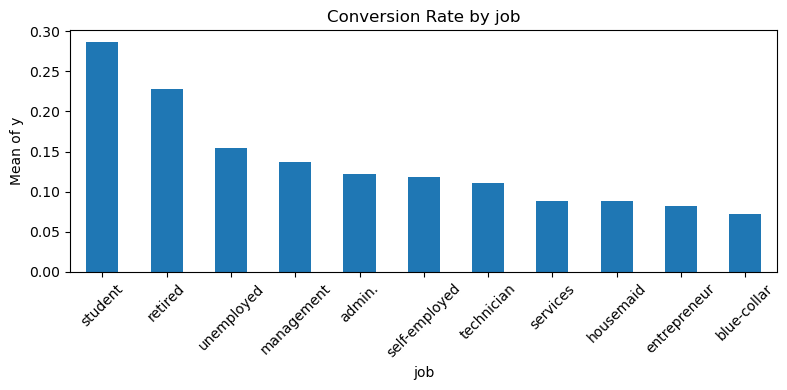


Conversion rate by marital:
marital
single      0.149492
divorced    0.119455
married     0.101235
Name: y, dtype: float64


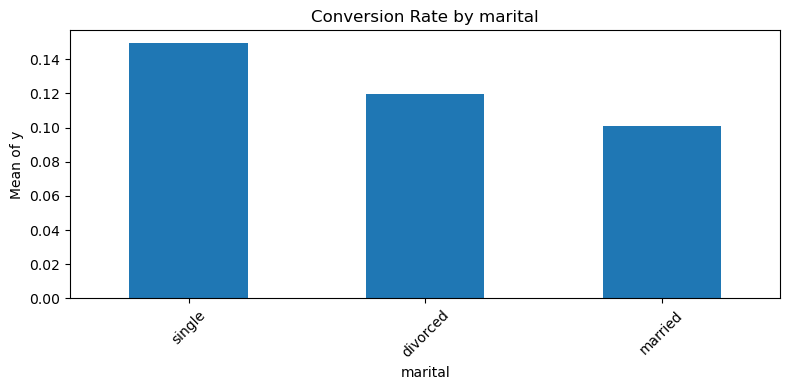


Conversion rate by education:
education
tertiary     0.150064
secondary    0.105594
primary      0.086265
Name: y, dtype: float64


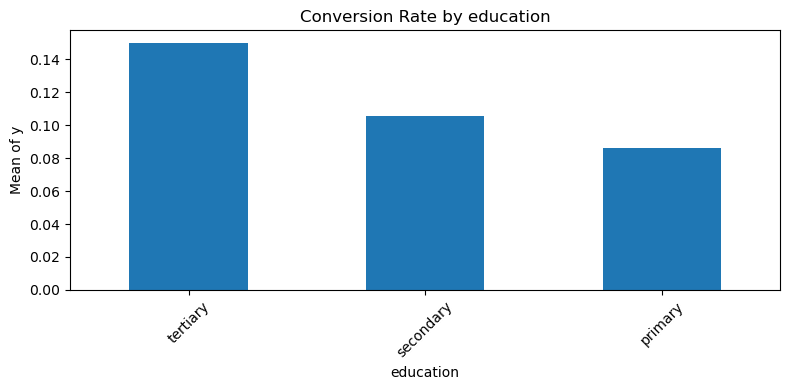


Conversion rate by default:
default
no     0.117961
yes    0.063804
Name: y, dtype: float64


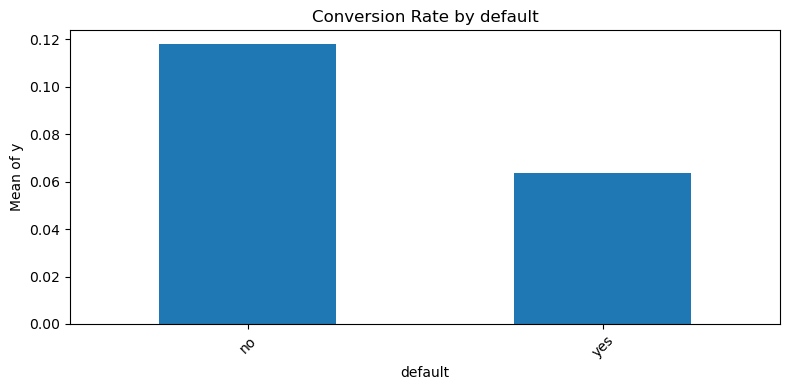


Conversion rate by housing:
housing
no     0.167024
yes    0.077000
Name: y, dtype: float64


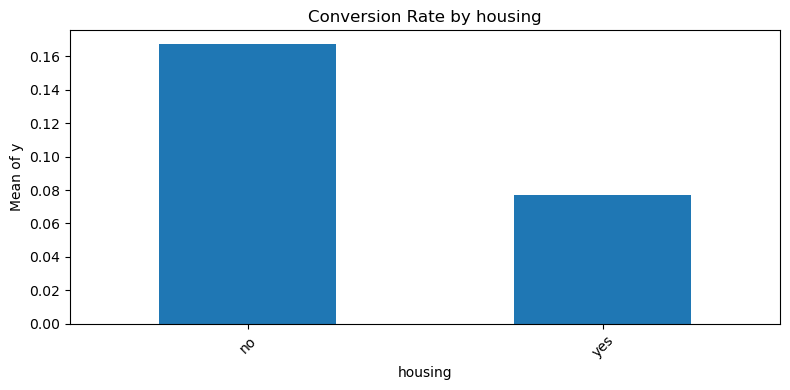


Conversion rate by loan:
loan
no     0.126557
yes    0.066814
Name: y, dtype: float64


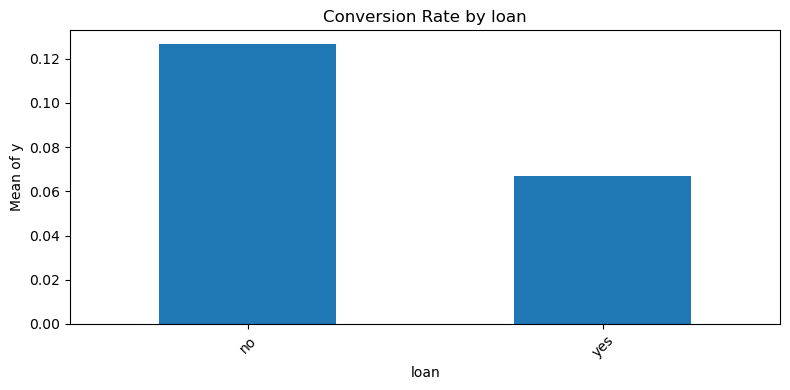


Conversion rate by contact:
contact
cellular     0.149189
telephone    0.134205
Name: y, dtype: float64


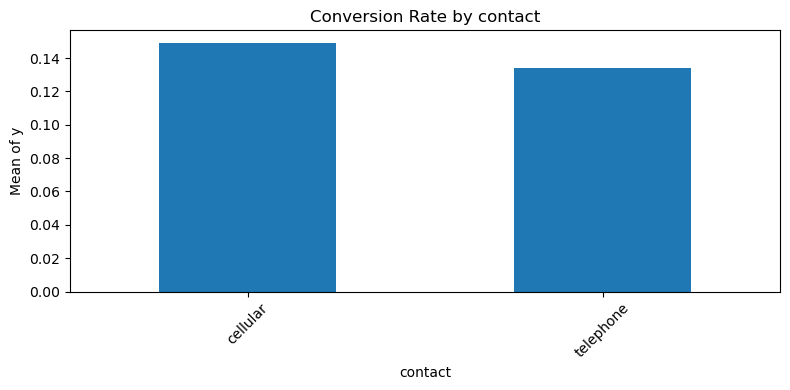


Conversion rate by month:
month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    0.196794
feb    0.166478
aug    0.110133
jun    0.102228
nov    0.101511
jan    0.101212
jul    0.090935
may    0.067195
Name: y, dtype: float64


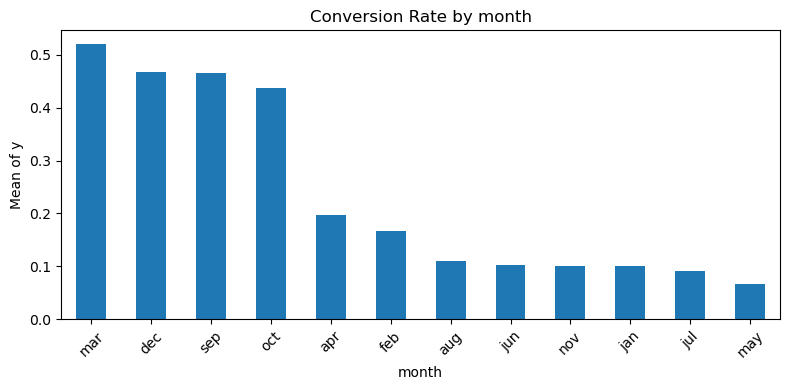


Conversion rate by day_of_week:
day_of_week
1     0.279503
10    0.230916
30    0.173052
22    0.170166
3     0.164968
4     0.159170
25    0.158333
12    0.152215
13    0.152050
2     0.140758
15    0.139753
24    0.138702
16    0.135689
23    0.134185
27    0.133809
11    0.122380
9     0.114670
14    0.113636
5     0.112565
26    0.112077
8     0.109121
21    0.099210
18    0.098787
6     0.093685
17    0.090768
7     0.086406
28    0.078142
29    0.073926
31    0.071540
20    0.069767
19    0.069437
Name: y, dtype: float64


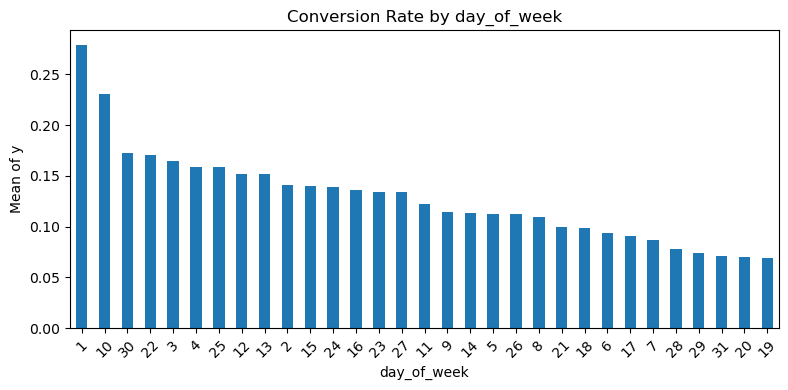


Conversion rate by poutcome:
poutcome
success    0.647253
other      0.166848
failure    0.126097
Name: y, dtype: float64


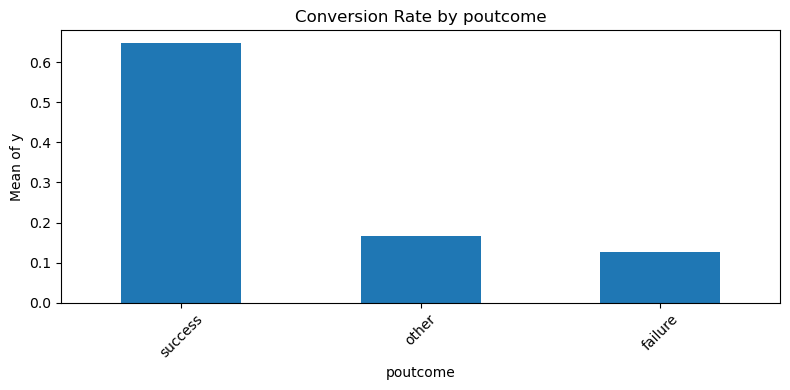

In [4]:
# 1.1 Missing values
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))

# 1.2 Target distribution
target_counts = df["y"].value_counts(dropna=False)
target_props = df["y"].value_counts(normalize=True, dropna=False)

print("\nTarget counts:")
print(target_counts)

print("\nTarget proportions:")
print(target_props)

plt.figure(figsize=(6, 4))
target_counts.sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("y")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 1.3 Identify feature types
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

# 1.4 Numeric summary
print("\nNumeric summary:")
print(df[numeric_cols].describe().T)

# 1.5 Correlation among numeric variables
corr = df[numeric_cols + ["y"]].corr(numeric_only=True)

print("\nCorrelation with target:")
print(corr["y"].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="RdBu_r", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# 1.6 Histograms of numeric variables
df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

# 1.7 Conversion rate by selected categorical variables
candidate_cat_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome",
]

for col in candidate_cat_cols:
    if col in df.columns:
        rate_table = df.groupby(col)["y"].mean().sort_values(ascending=False)
        print(f"\nConversion rate by {col}:")
        print(rate_table)

        plt.figure(figsize=(8, 4))
        rate_table.plot(kind="bar")
        plt.title(f"Conversion Rate by {col}")
        plt.ylabel("Mean of y")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

## test&train setup

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())


Train shape: (36168, 16)
Test shape: (9043, 16)
Train positive rate: 0.11698186241981863
Test positive rate: 0.11699657193409267


In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

## Model evaluation

In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "model": model_name,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "train_precision": precision_score(y_train, y_train_pred, zero_division=0),
        "test_precision": precision_score(y_test, y_test_pred, zero_division=0),
        "train_recall": recall_score(y_train, y_train_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_test_pred, zero_division=0),
        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
        "train_auc": roc_auc_score(y_train, y_train_prob),
        "test_auc": roc_auc_score(y_test, y_test_prob),
    }

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    for k, v in results.items():
        if k != "model":
            print(f"{k}: {v:.4f}")

    print("\nConfusion Matrix (Test):")
    print(confusion_matrix(y_test, y_test_pred))

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    return results, model

## Weighted Logit

In [8]:
logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
                random_state=42,
            ),
        ),
    ]
)

logit_results, fitted_logit = evaluate_model(
    logit_model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name="Weighted Logistic Regression",
)


Weighted Logistic Regression
train_accuracy: 0.8415
test_accuracy: 0.8387
train_precision: 0.4099
test_precision: 0.4029
train_recall: 0.8069
test_recall: 0.7864
train_f1: 0.5436
test_f1: 0.5328
train_auc: 0.9057
test_auc: 0.9020

Confusion Matrix (Test):
[[6752 1233]
 [ 226  832]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.97      0.85      0.90      7985
           1       0.40      0.79      0.53      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.82      0.72      9043
weighted avg       0.90      0.84      0.86      9043



## Random forest

In [9]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_split=10,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_results, fitted_rf = evaluate_model(
    rf_model, X_train, X_test, y_train, y_test, model_name="Random Forest"
)


Random Forest
train_accuracy: 0.9088
test_accuracy: 0.8775
train_precision: 0.5660
test_precision: 0.4852
train_recall: 0.9461
test_recall: 0.7769
train_f1: 0.7082
test_f1: 0.5974
train_auc: 0.9784
test_auc: 0.9224

Confusion Matrix (Test):
[[7113  872]
 [ 236  822]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.97      0.89      0.93      7985
           1       0.49      0.78      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.83      0.76      9043
weighted avg       0.91      0.88      0.89      9043



## XGBoost

In [10]:
from xgboost import XGBClassifier

# scale_pos_weight = (# negative) / (# positive)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
            ),
        ),
    ]
)

xgb_results, fitted_xgb = evaluate_model(
    xgb_model, X_train, X_test, y_train, y_test, model_name="XGBoost"
)


XGBoost
train_accuracy: 0.8714
test_accuracy: 0.8555
train_precision: 0.4745
test_precision: 0.4390
train_recall: 0.9241
test_recall: 0.8469
train_f1: 0.6270
test_f1: 0.5783
train_auc: 0.9564
test_auc: 0.9263

Confusion Matrix (Test):
[[6840 1145]
 [ 162  896]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.86      0.91      7985
           1       0.44      0.85      0.58      1058

    accuracy                           0.86      9043
   macro avg       0.71      0.85      0.75      9043
weighted avg       0.91      0.86      0.87      9043



## comparison

In [11]:
results_df = pd.DataFrame([logit_results, rf_results, xgb_results])

print("\nModel comparison:")
print(
    results_df[
        [
            "model",
            "test_accuracy",
            "test_precision",
            "test_recall",
            "test_f1",
            "test_auc",
        ]
    ].sort_values("test_auc", ascending=False)
)


Model comparison:
                          model  test_accuracy  test_precision  test_recall  \
2                       XGBoost       0.855468        0.439000     0.846881   
1                 Random Forest       0.877474        0.485242     0.776938   
0  Weighted Logistic Regression       0.838660        0.402906     0.786389   

    test_f1  test_auc  
2  0.578251  0.926342  
1  0.597384  0.922372  
0  0.532821  0.901950  



Top 15 positive logistic coefficients:
               feature  coefficient
39           month_mar     1.810822
46    poutcome_success     1.646451
3             duration     1.494467
42           month_oct     1.276561
43           month_sep     0.961297
34           month_dec     0.896103
15         job_student     0.721766
12         job_retired     0.598093
26          housing_no     0.501278
28             loan_no     0.341438
23  education_tertiary     0.325793
32           month_apr     0.242255
20      marital_single     0.212615
7           job_admin.     0.190922
24          default_no     0.163215

Top 15 negative logistic coefficients:
              feature  coefficient
9    job_entrepreneur    -0.225782
21  education_primary    -0.245811
8     job_blue-collar    -0.257614
4            campaign    -0.285898
13  job_self-employed    -0.299263
10      job_housemaid    -0.341968
27        housing_yes    -0.385172
38          month_jun    -0.516947
45     poutcome_other    -0.5

/Users/a27398/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


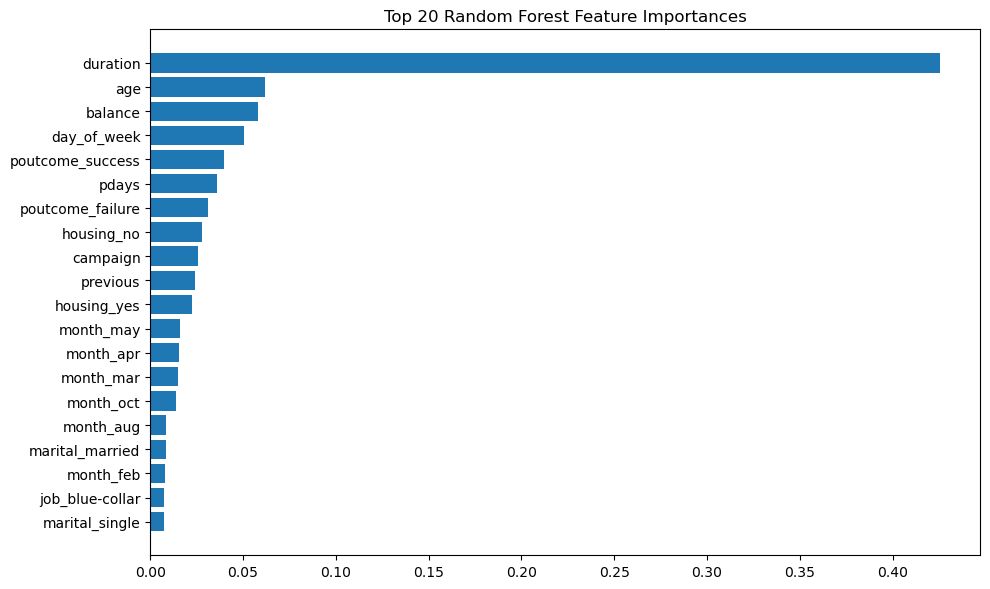


Top 20 XGBoost feature importances:
               feature  importance
44    poutcome_failure    0.113981
46    poutcome_success    0.107942
3             duration    0.071126
27         housing_yes    0.053832
39           month_mar    0.051550
26          housing_no    0.050160
42           month_oct    0.038923
40           month_may    0.037513
32           month_apr    0.028393
37           month_jul    0.026478
35           month_feb    0.024659
43           month_sep    0.024535
41           month_nov    0.023888
45      poutcome_other    0.022244
8      job_blue-collar    0.021634
29            loan_yes    0.019617
28             loan_no    0.019576
33           month_aug    0.016991
5                pdays    0.015969
23  education_tertiary    0.015464


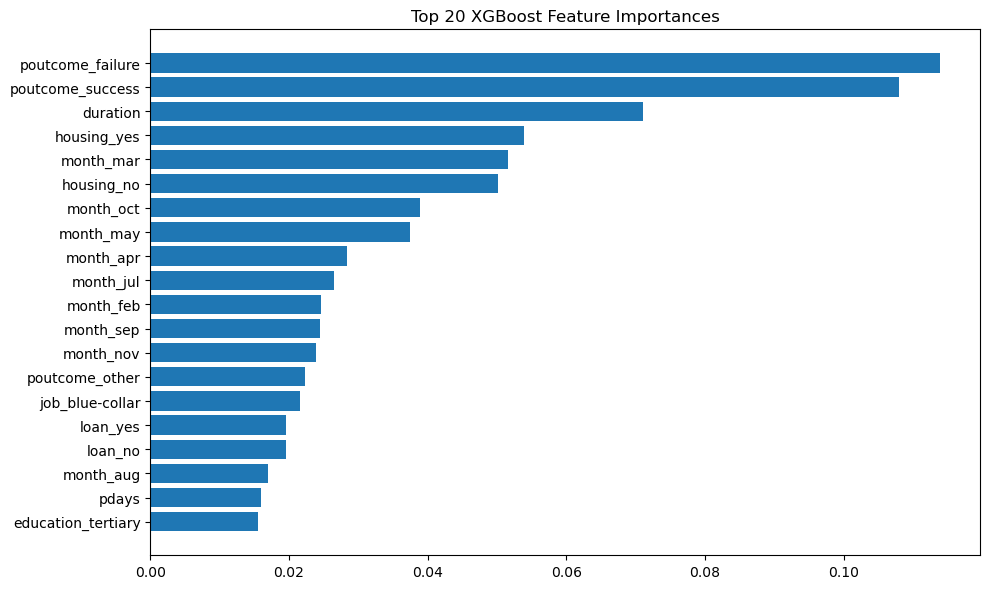


Best threshold (logistic): 0.719
Best F1 at this threshold: 0.5731

Custom-threshold test metrics:
Accuracy: 0.8896
Precision: 0.5234
Recall: 0.6333
F1: 0.5731
AUC: 0.902

Top scored customers:
       age           job  marital  education default  balance housing loan  \
24095   30        admin.  married  secondary      no     1310      no   no   
42534   68       retired  married  secondary      no     1443      no   no   
11386   45    technician  married   tertiary      no     3626      no   no   
30324   26  entrepreneur   single   tertiary      no      725      no   no   
26830   41    technician   single  secondary      no      650     yes   no   

         contact  day_of_week month  duration  campaign  pdays  previous  \
24095  telephone           27   oct      3284         1     -1         0   
42534  telephone           21   dec      2062         2    257         1   
11386        NaN           19   jun      2485         2     -1         0   
30324   cellular            5   

In [ ]:
# =========================================================
# 8. Logistic coefficients
# =========================================================
ohe = (
    fitted_logit.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numeric_cols, cat_feature_names])

logit_clf = fitted_logit.named_steps["classifier"]

coef_df = pd.DataFrame(
    {"feature": all_feature_names, "coefficient": logit_clf.coef_[0]}
).sort_values("coefficient", ascending=False)

print("\nTop 15 positive logistic coefficients:")
print(coef_df.head(15))

print("\nTop 15 negative logistic coefficients:")
print(coef_df.tail(15))

import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================================================
# 8A. Get feature names from the fitted sklearn pipeline
# =========================================================
ohe = (
    fitted_logit.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([numeric_cols, cat_feature_names])

# =========================================================
# 8B. Build transformed training design matrix
# =========================================================
X_train_processed = fitted_logit.named_steps["preprocessor"].transform(X_train)

# if sparse, convert to dense
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

X_train_processed = pd.DataFrame(X_train_processed, columns=all_feature_names)

# add constant for statsmodels
X_train_sm = sm.add_constant(X_train_processed, has_constant="add")

# make sure y is 1D numeric
y_train_sm = np.ravel(y_train).astype(float)

# =========================================================
# 8C. Fit statsmodels Logit
# =========================================================
logit_sm = sm.Logit(y_train_sm, X_train_sm)
result = logit_sm.fit(disp=False)

# =========================================================
# 8D. Collect coefficient table
# =========================================================
coef_table = pd.DataFrame(
    {
        "feature": result.params.index,
        "coefficient": result.params.values,
        "std_error": result.bse.values,
        "z_value": result.tvalues.values,  # for Logit, this is effectively z
        "p_value": result.pvalues.values,
    }
)

# remove intercept if you don't want it
coef_table = coef_table[coef_table["feature"] != "const"]

# sort by coefficient
coef_table_sorted = coef_table.sort_values("coefficient", ascending=False)

print("\nTop 15 positive logistic coefficients with z-values:")
print(coef_table_sorted.head(15))

print("\nTop 15 negative logistic coefficients with z-values:")
print(coef_table_sorted.tail(15))

# =========================================================
# 9. Random Forest feature importance
# =========================================================
rf_clf = fitted_rf.named_steps["classifier"]

feature_importance_df = pd.DataFrame(
    {"feature": all_feature_names, "importance": rf_clf.feature_importances_}
).sort_values("importance", ascending=False)

print("\nTop 20 Random Forest feature importances:")
print(feature_importance_df.head(20))

plt.figure(figsize=(10, 6))
top_n = 20
plt.barh(
    feature_importance_df.head(top_n)["feature"][::-1],
    feature_importance_df.head(top_n)["importance"][::-1],
)
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# =========================================================
# 9B. XGBoost feature importance
# =========================================================
ohe_xgb = (
    fitted_xgb.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)
cat_feature_names_xgb = ohe_xgb.get_feature_names_out(categorical_cols)
all_feature_names_xgb = np.concatenate([numeric_cols, cat_feature_names_xgb])

xgb_clf = fitted_xgb.named_steps["classifier"]

xgb_importance_df = pd.DataFrame(
    {"feature": all_feature_names_xgb, "importance": xgb_clf.feature_importances_}
).sort_values("importance", ascending=False)

print("\nTop 20 XGBoost feature importances:")
print(xgb_importance_df.head(20))

plt.figure(figsize=(10, 6))
top_n = 20
plt.barh(
    xgb_importance_df.head(top_n)["feature"][::-1],
    xgb_importance_df.head(top_n)["importance"][::-1],
)
plt.title("Top 20 XGBoost Feature Importances")
plt.tight_layout()
plt.show()
# =========================================================
# 10. Optional: threshold tuning for logistic regression
# =========================================================
y_test_prob_logit = fitted_logit.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob_logit)

f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("\nBest threshold (logistic):", round(best_threshold, 4))
print("Best F1 at this threshold:", round(f1_scores[best_idx], 4))

y_test_pred_custom = (y_test_prob_logit >= best_threshold).astype(int)

print("\nCustom-threshold test metrics:")
print("Accuracy:", round(accuracy_score(y_test, y_test_pred_custom), 4))
print(
    "Precision:", round(precision_score(y_test, y_test_pred_custom, zero_division=0), 4)
)
print("Recall:", round(recall_score(y_test, y_test_pred_custom, zero_division=0), 4))
print("F1:", round(f1_score(y_test, y_test_pred_custom, zero_division=0), 4))
print("AUC:", round(roc_auc_score(y_test, y_test_prob_logit), 4))


# =========================================================
# 11. Create scored customers for later optimization
# =========================================================
scored_test = X_test.copy()
scored_test["actual_y"] = y_test.values
scored_test["pred_prob_logit"] = fitted_logit.predict_proba(X_test)[:, 1]
scored_test["pred_prob_rf"] = fitted_rf.predict_proba(X_test)[:, 1]

scored_test = scored_test.sort_values("pred_prob_logit", ascending=False)

print("\nTop scored customers:")
print(scored_test.head())

save_path = r"/Users/a27398/Documents/Duke/26Spring/MATH586/Class Project/scored_customers_for_optimization.csv"
scored_test.to_csv(save_path, index=False)
print("Saved to:", save_path)

# =========================================================
# 11B. Add XGBoost scores for later optimization
# =========================================================
scored_test["pred_prob_xgb"] = fitted_xgb.predict_proba(X_test)[:, 1]

scored_test = scored_test.sort_values("pred_prob_xgb", ascending=False)

print("\nTop scored customers by XGBoost:")
print(scored_test.head())

scored_test.to_csv(save_path, index=False)

### We note that duration is highly predictive, but since it is only observed after contact occurs, it may not be available for real-time targeting decisions. Therefore, in implementation, a pre-contact version of the model may exclude this variable.

## Optimization

During implementation, we identified and corrected an index-alignment issue when combining predicted probabilities with out-of-sample labels. After fixing the alignment, the ranking performance became consistent with the strong AUC results, and the top-ranked customers showed higher realized conversion rates than the overall test sample.

In [13]:
scored_test = X_test.reset_index(drop=True).copy()
scored_test["actual_y"] = y_test.reset_index(drop=True)
scored_test["pred_prob_logit"] = fitted_logit.predict_proba(X_test)[:, 1]
scored_test["pred_prob_rf"] = fitted_rf.predict_proba(X_test)[:, 1]
scored_test["pred_prob_xgb"] = fitted_xgb.predict_proba(X_test)[:, 1]

In [14]:
# =========================================================
# 4) OPTIMIZATION
# Goal: choose which customers to target under a budget
# =========================================================
# Assumption:
# - Each contacted customer costs contact_cost
# - If a customer converts, bank earns revenue_if_success
# - Expected profit_i = p_i * revenue_if_success - contact_cost
# - Decision variable z_i in {0,1}: target customer i or not
# - Constraint: total contact cost <= budget
#
# Since contact cost is constant here, the optimal solution is:
# target the customers with the highest positive expected profit,
# subject to the budget limit.
# =========================================================

import numpy as np
import pandas as pd

# -------- choose which model score to use --------
# options: "pred_prob_logit", "pred_prob_rf", "pred_prob_xgb"
score_col = "pred_prob_xgb"

# -------- business assumptions --------
contact_cost = 10  # cost per contact
revenue_if_success = 120  # revenue from one successful conversion
budget = 50000  # total campaign budget

# copy scored data
opt_df = scored_test.copy().reset_index(drop=True)

# expected profit per customer
opt_df["expected_profit"] = opt_df[score_col] * revenue_if_success - contact_cost

# only target customers with positive expected profit
opt_df = opt_df[opt_df["expected_profit"] > 0].copy()

# sort by expected profit descending
opt_df = opt_df.sort_values("expected_profit", ascending=False).reset_index(drop=True)

# max number of customers we can target under budget
max_targets = int(budget // contact_cost)

# optimal targeting set
optimal_targets = opt_df.head(max_targets).copy()
optimal_targets["target_flag"] = 1

# summary
total_targeted = len(optimal_targets)
total_cost = total_targeted * contact_cost
expected_conversions = optimal_targets[score_col].sum()
expected_revenue = expected_conversions * revenue_if_success
expected_profit_total = expected_revenue - total_cost

print("========== OPTIMIZATION SUMMARY ==========")
print("Model score used:", score_col)
print("Budget:", budget)
print("Contact cost:", contact_cost)
print("Revenue per success:", revenue_if_success)
print("Total targeted customers:", total_targeted)
print("Total expected conversions:", round(expected_conversions, 2))
print("Total expected revenue:", round(expected_revenue, 2))
print("Total cost:", round(total_cost, 2))
print("Total expected profit:", round(expected_profit_total, 2))

print("\nTop optimized targets:")
print(optimal_targets[[score_col, "expected_profit", "actual_y"]].head())

# save optimization result
optimization_result = optimal_targets.copy()

========== OPTIMIZATION SUMMARY ==========
Model score used: pred_prob_xgb
Budget: 50000
Contact cost: 10
Revenue per success: 120
Total targeted customers: 4678
Total expected conversions: 2206.29
Total expected revenue: 264754.6
Total cost: 46780
Total expected profit: 217974.6

Top optimized targets:
   pred_prob_xgb  expected_profit  actual_y
0       0.992870       109.144417         1
1       0.992706       109.124702         1
2       0.990872       108.904594         1
3       0.990741       108.888939         1
4       0.990018       108.802170         1


In [15]:
# =========================================================
# 4B) ALTERNATIVE OPTIMIZATION WITH DIFFERENT BUDGETS
# Useful for sensitivity analysis in the report / slides
# =========================================================

budgets = [10000, 20000, 30000, 40000, 50000, 75000, 100000]
sensitivity_rows = []

base_df = scored_test.copy().reset_index(drop=True)
base_df["expected_profit"] = base_df[score_col] * revenue_if_success - contact_cost
base_df = base_df[base_df["expected_profit"] > 0].copy()
base_df = base_df.sort_values("expected_profit", ascending=False).reset_index(drop=True)

for b in budgets:
    n = int(b // contact_cost)
    chosen = base_df.head(n).copy()

    exp_conv = chosen[score_col].sum()
    exp_rev = exp_conv * revenue_if_success
    total_cost = len(chosen) * contact_cost
    exp_profit = exp_rev - total_cost

    sensitivity_rows.append(
        {
            "budget": b,
            "n_targeted": len(chosen),
            "expected_conversions": exp_conv,
            "expected_revenue": exp_rev,
            "total_cost": total_cost,
            "expected_profit": exp_profit,
        }
    )

budget_sensitivity = pd.DataFrame(sensitivity_rows)
print(budget_sensitivity)

   budget  n_targeted  expected_conversions  expected_revenue  total_cost  \
0   10000        1000            902.183899     108262.070312       10000   
1   20000        2000           1574.927979     188991.359375       20000   
2   30000        3000           1950.710327     234085.234375       30000   
3   40000        4000           2136.042236     256325.062500       40000   
4   50000        4678           2206.288330     264754.593750       46780   
5   75000        4678           2206.288330     264754.593750       46780   
6  100000        4678           2206.288330     264754.593750       46780   

   expected_profit  
0     98262.070312  
1    168991.359375  
2    204085.234375  
3    216325.062500  
4    217974.593750  
5    217974.593750  
6    217974.593750  


In [16]:
top_check = scored_test.sort_values("pred_prob_xgb", ascending=False).head(500)
print("Top 500 actual conversion rate:", top_check["actual_y"].mean())

top_check = scored_test.sort_values("pred_prob_xgb", ascending=False).head(1000)
print("Top 1000 actual conversion rate:", top_check["actual_y"].mean())

print("Overall actual conversion rate:", scored_test["actual_y"].mean())

Top 500 actual conversion rate: 0.704
Top 1000 actual conversion rate: 0.597
Overall actual conversion rate: 0.11699657193409267


## Backtesting

In [17]:
# =========================================================
# 5) BACKTESTING + BUSINESS IMPACT
# Compare:
# 1. optimized targeting strategy
# 2. random targeting
# 3. target everyone allowed by budget without ranking
# 4. top-N by other models if you want
# =========================================================


# ---------- business metric function ----------
def evaluate_campaign(df, selected_idx, revenue_if_success=120, contact_cost=10):
    chosen = df.loc[selected_idx].copy()

    actual_conversions = chosen["actual_y"].sum()
    total_targeted = len(chosen)
    total_cost = total_targeted * contact_cost
    actual_revenue = actual_conversions * revenue_if_success
    actual_profit = actual_revenue - total_cost
    conversion_rate = chosen["actual_y"].mean() if total_targeted > 0 else 0

    return {
        "n_targeted": total_targeted,
        "actual_conversions": actual_conversions,
        "conversion_rate": conversion_rate,
        "actual_revenue": actual_revenue,
        "total_cost": total_cost,
        "actual_profit": actual_profit,
    }


# ---------- prepare full test set ----------
bt_df = scored_test.copy().reset_index(drop=True)

# number of customers we are allowed to target
n_target = int(budget // contact_cost)

# ---------- strategy 1: optimized by chosen model ----------
optimized_idx = bt_df.sort_values(score_col, ascending=False).head(n_target).index

optimized_metrics = evaluate_campaign(
    bt_df,
    optimized_idx,
    revenue_if_success=revenue_if_success,
    contact_cost=contact_cost,
)

print("Optimized strategy:")
print(optimized_metrics)

# ---------- strategy 2: random targeting ----------
n_random_trials = 200
random_results = []

for seed in range(n_random_trials):
    random_idx = bt_df.sample(n=n_target, random_state=seed, replace=False).index
    metrics = evaluate_campaign(
        bt_df,
        random_idx,
        revenue_if_success=revenue_if_success,
        contact_cost=contact_cost,
    )
    random_results.append(metrics)

random_df = pd.DataFrame(random_results)
random_avg = random_df.mean(numeric_only=True).to_dict()

print("\nAverage random strategy:")
print(random_avg)

# ---------- strategy 3: if bank contacts first n_target customers without scoring ----------
first_n_idx = bt_df.head(n_target).index
naive_metrics = evaluate_campaign(
    bt_df, first_n_idx, revenue_if_success=revenue_if_success, contact_cost=contact_cost
)

print("\nNaive first-N strategy:")
print(naive_metrics)

# ---------- strategy 4: compare all models ----------
strategy_rows = []

for model_score in ["pred_prob_logit", "pred_prob_rf", "pred_prob_xgb"]:
    if model_score in bt_df.columns:
        idx = bt_df.sort_values(model_score, ascending=False).head(n_target).index
        m = evaluate_campaign(
            bt_df, idx, revenue_if_success=revenue_if_success, contact_cost=contact_cost
        )
        m["strategy"] = model_score
        strategy_rows.append(m)

# add random average
random_avg_row = random_avg.copy()
random_avg_row["strategy"] = "random_avg"
strategy_rows.append(random_avg_row)

# add naive first-N
naive_row = naive_metrics.copy()
naive_row["strategy"] = "first_n_no_model"
strategy_rows.append(naive_row)

strategy_comparison = pd.DataFrame(strategy_rows)
strategy_comparison = strategy_comparison[
    [
        "strategy",
        "n_targeted",
        "actual_conversions",
        "conversion_rate",
        "actual_revenue",
        "total_cost",
        "actual_profit",
    ]
].sort_values("actual_profit", ascending=False)

print("\n========== BACKTESTING COMPARISON ==========")
print(strategy_comparison)

Optimized strategy:
{'n_targeted': 5000, 'actual_conversions': np.int64(1043), 'conversion_rate': np.float64(0.2086), 'actual_revenue': np.int64(125160), 'total_cost': 50000, 'actual_profit': np.int64(75160)}

Average random strategy:
{'n_targeted': 5000.0, 'actual_conversions': 586.805, 'conversion_rate': 0.11736100000000001, 'actual_revenue': 70416.6, 'total_cost': 50000.0, 'actual_profit': 20416.6}

Naive first-N strategy:
{'n_targeted': 5000, 'actual_conversions': np.int64(571), 'conversion_rate': np.float64(0.1142), 'actual_revenue': np.int64(68520), 'total_cost': 50000, 'actual_profit': np.int64(18520)}

========== BACKTESTING COMPARISON ==========
           strategy  n_targeted  actual_conversions  conversion_rate  \
1      pred_prob_rf      5000.0            1045.000         0.209000   
2     pred_prob_xgb      5000.0            1043.000         0.208600   
0   pred_prob_logit      5000.0            1036.000         0.207200   
3        random_avg      5000.0             586.8

In [18]:
# =========================================================
# 5B) LIFT / TOP-DECILE STYLE BUSINESS IMPACT
# Show whether the model concentrates conversions in top-ranked customers
# =========================================================


lift_df = scored_test.copy().reset_index(drop=True)

score_for_lift = "pred_prob_xgb"  # choose one
lift_df = lift_df.sort_values(score_for_lift, ascending=False).reset_index(drop=True)

# deciles
lift_df["decile"] = pd.qcut(np.arange(len(lift_df)), 10, labels=False) + 1

# decile 1 = top 10%, but qcut on sorted order makes bottom label start at 1
# so reverse labels
lift_df["decile"] = 11 - lift_df["decile"]

lift_table = (
    lift_df.groupby("decile")
    .agg(
        n_customers=("actual_y", "size"),
        actual_conversions=("actual_y", "sum"),
        avg_actual_conversion_rate=("actual_y", "mean"),
        avg_predicted_probability=(score_for_lift, "mean"),
    )
    .reset_index()
    .sort_values("decile")
)

overall_rate = lift_df["actual_y"].mean()
lift_table["lift_vs_overall"] = lift_table["avg_actual_conversion_rate"] / overall_rate

print(lift_table)
print("\nOverall conversion rate:", round(overall_rate, 4))

   decile  n_customers  actual_conversions  avg_actual_conversion_rate  \
0       1          905                   1                    0.001105   
1       2          904                   1                    0.001106   
2       3          904                   4                    0.004425   
3       4          904                   4                    0.004425   
4       5          904                  10                    0.011062   
5       6          905                  12                    0.013260   
6       7          904                  40                    0.044248   
7       8          904                 125                    0.138274   
8       9          904                 301                    0.332965   
9      10          905                 560                    0.618785   

   avg_predicted_probability  lift_vs_overall  
0                   0.002508         0.009444  
1                   0.009132         0.009455  
2                   0.020233         0.03

In [19]:
# =========================================================
# 5C) SIMPLE BUSINESS INTERPRETATION OUTPUT
# =========================================================

best_row = strategy_comparison.iloc[0]
random_profit = strategy_comparison.loc[
    strategy_comparison["strategy"] == "random_avg", "actual_profit"
].iloc[0]

profit_lift_vs_random = best_row["actual_profit"] - random_profit

print("========== BUSINESS IMPACT ==========")
print(f"Best strategy: {best_row['strategy']}")
print(f"Targeted customers: {int(best_row['n_targeted'])}")
print(f"Actual conversions: {int(best_row['actual_conversions'])}")
print(f"Conversion rate: {best_row['conversion_rate']:.4f}")
print(f"Actual profit: {best_row['actual_profit']:.2f}")
print(f"Profit improvement vs random: {profit_lift_vs_random:.2f}")

if random_profit != 0:
    print(
        f"Relative uplift vs random: {profit_lift_vs_random / abs(random_profit):.2%}"
    )

========== BUSINESS IMPACT ==========
Best strategy: pred_prob_rf
Targeted customers: 5000
Actual conversions: 1045
Conversion rate: 0.2090
Actual profit: 75400.00
Profit improvement vs random: 54983.40
Relative uplift vs random: 269.31%


In [20]:
# =========================================================
# 5D) SAVE RESULTS
# =========================================================

import os

folder_path = r"/Users/a27398/Documents/Duke/26Spring/MATH586/Class Project"
os.makedirs(folder_path, exist_ok=True)

strategy_comparison.to_csv(
    os.path.join(folder_path, "backtesting_strategy_comparison.csv"), index=False
)

budget_sensitivity.to_csv(
    os.path.join(folder_path, "budget_sensitivity.csv"), index=False
)

optimization_result.to_csv(
    os.path.join(folder_path, "optimization_result.csv"), index=False
)

lift_table.to_csv(os.path.join(folder_path, "lift_table.csv"), index=False)

print("All files saved.")

All files saved.


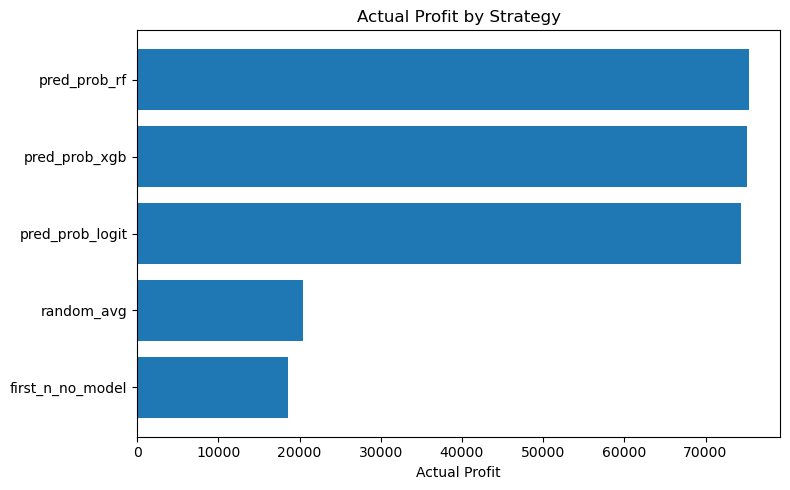

In [21]:
# =========================================================
# 5E) OPTIONAL PLOT: profit by strategy
# =========================================================

import matplotlib.pyplot as plt

plot_df = strategy_comparison.sort_values("actual_profit", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["strategy"], plot_df["actual_profit"])
plt.title("Actual Profit by Strategy")
plt.xlabel("Actual Profit")
plt.tight_layout()
plt.show()

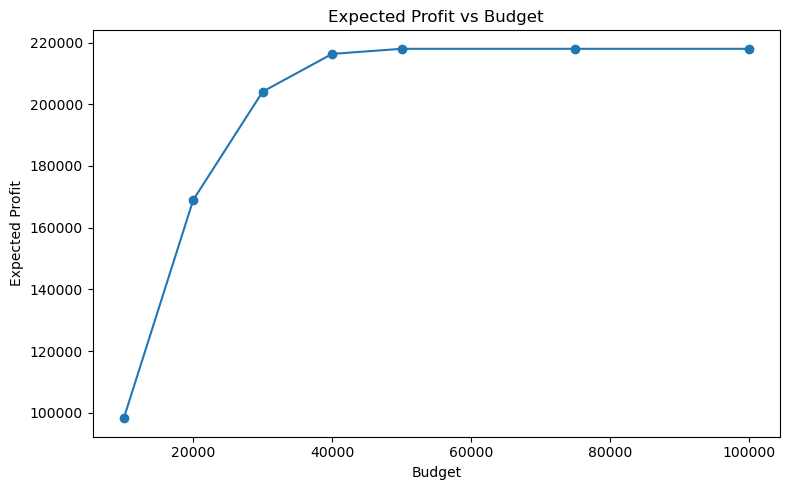

In [22]:
# =========================================================
# 5F) OPTIONAL PLOT: expected profit vs budget
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(
    budget_sensitivity["budget"], budget_sensitivity["expected_profit"], marker="o"
)
plt.title("Expected Profit vs Budget")
plt.xlabel("Budget")
plt.ylabel("Expected Profit")
plt.tight_layout()
plt.show()

========== DECISION SUMMARY ==========


,Metric,Value
0,Total customers in candidate set,9043
1,Customers with positive expected profit,5649
2,Maximum calls allowed by budget,3000
3,Customers actually selected to call,3000
4,Customers not selected,6043
5,Did we call everyone?,False
6,Budget fully used?,True
7,Average expected profit of called customers,84.08
8,Average expected profit of not-called customers,1.44
9,Expected total profit of called customers,252240.45


========== TOP 20 CALLED CUSTOMERS ==========


,customer_id,pred_prob_rf,expected_profit,A_i,V_i,reason_tag,actual_y,age,job,marital,education,balance,housing,loan,previous,poutcome,call_decision
0,7249,0.956164,258.299688,8000,280.6,High probability + high value,1,42,management,married,tertiary,27696,no,no,7,success,CALL
1,1545,0.955963,258.243188,8000,280.6,High probability + high value,1,72,retired,married,secondary,5715,no,no,2,success,CALL
2,8159,0.949686,256.482005,8000,280.6,High probability + high value,1,41,unemployed,single,tertiary,7968,no,no,4,success,CALL
3,766,0.948119,256.042256,8000,280.6,High probability + high value,1,57,management,married,tertiary,10583,no,no,3,success,CALL
4,1255,0.947853,255.967569,8000,280.6,High probability + high value,1,30,management,single,tertiary,5359,no,no,3,success,CALL
5,4161,0.945936,255.429508,8000,280.6,High probability + high value,1,32,technician,single,tertiary,5514,no,no,1,success,CALL
6,2664,0.941865,254.287221,8000,280.6,High probability + high value,1,61,self-employed,married,tertiary,10861,no,no,3,success,CALL
7,2388,0.924363,249.376233,8000,280.6,High probability + high value,0,61,management,married,tertiary,13546,no,no,3,success,CALL
8,4914,0.919239,247.938582,8000,280.6,High probability + high value,0,80,retired,married,secondary,8304,no,no,11,success,CALL
9,2427,0.915365,246.851512,8000,280.6,High probability + high value,1,54,management,married,tertiary,8295,no,no,1,success,CALL


========== PROFILE SUMMARY ==========


...

,loan,share
0,no,0.9087
1,yes,0.0913


========== TOP POUTCOME DISTRIBUTION AMONG CALLED CUSTOMERS ==========


,poutcome,share
0,Missing,0.6970
1,failure,0.1377
2,success,0.1013
3,other,0.0640


========== WHY SOME CUSTOMERS WERE NOT CALLED ==========


,Reason,Count
0,Expected profit <= 0,3394
1,Positive expected profit but not enough budget,2649


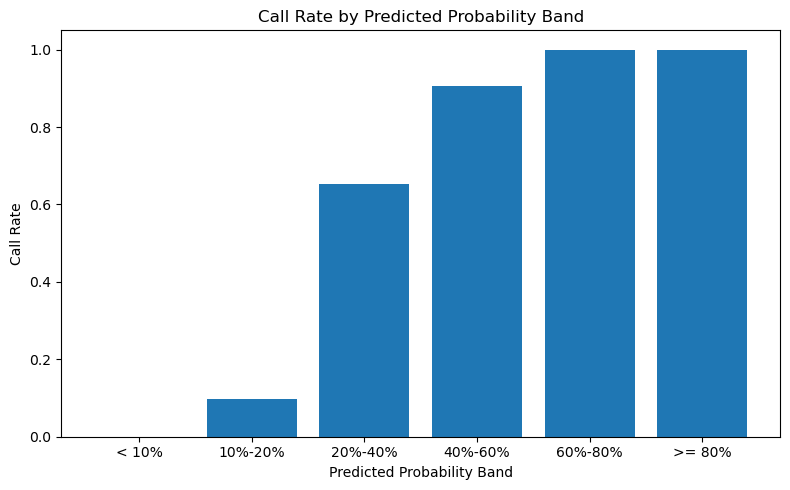

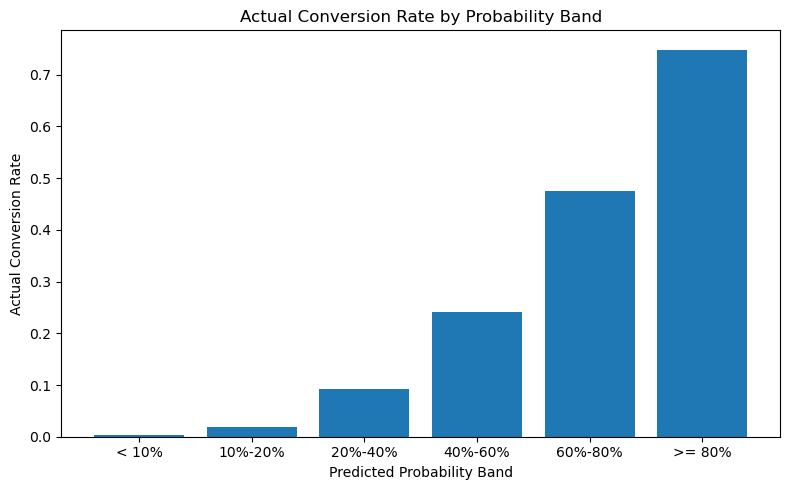

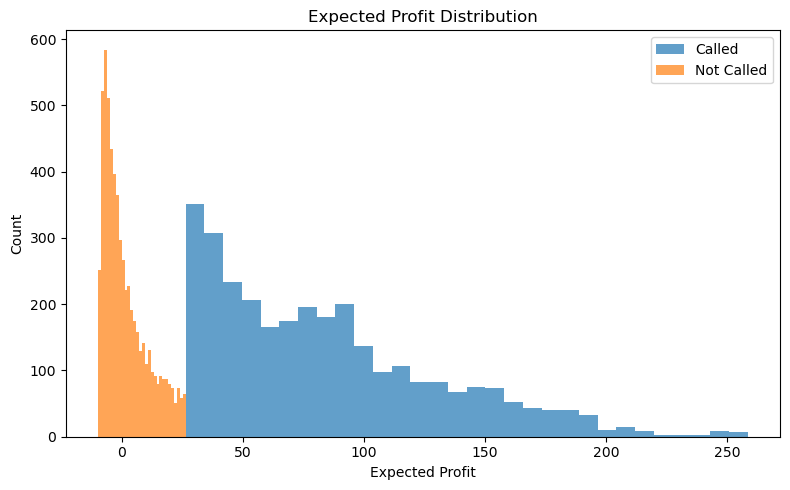

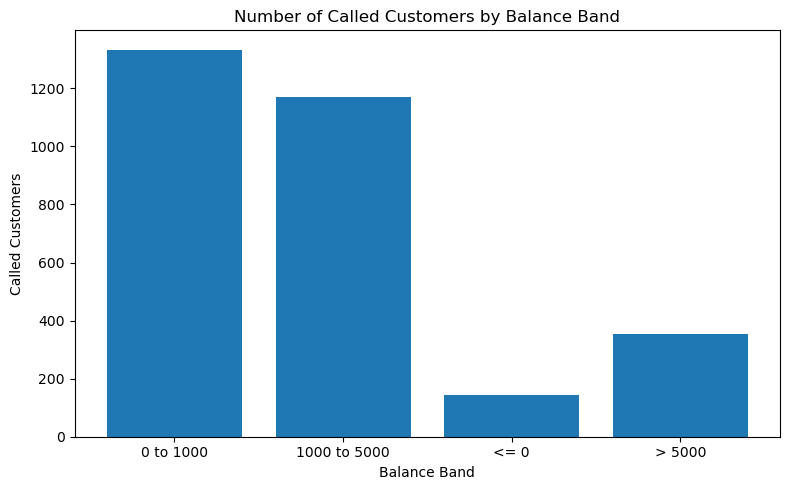

Outputs saved to: ./optimization_outputs


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================================================
# 0) USER SETTINGS
# =========================================================
score_col = "pred_prob_rf"  # choose: pred_prob_logit / pred_prob_rf / pred_prob_xgb

# budget and cost assumptions
budget = 30000
c_contact = 10
spread = 0.0357
T = 1.0
c_service = 5
c_promo = 0

# choose deposit amount scenario: "conservative", "base", "optimistic"
deposit_scenario_name = "base"

# top rows to preview
top_n_preview = 20

# save outputs
save_outputs = True
output_folder = "./optimization_outputs"


# =========================================================
# 1) DEPOSIT AMOUNT SCENARIOS
# =========================================================
deposit_scenarios = {
    "conservative": {"non_positive": 1500, "low": 3000, "mid": 4500, "high": 6000},
    "base": {"non_positive": 2000, "low": 4000, "mid": 6000, "high": 8000},
    "optimistic": {"non_positive": 2500, "low": 5000, "mid": 7500, "high": 10000},
}


# =========================================================
# 2) HELPER FUNCTIONS
# =========================================================
def assign_deposit_amount(balance, scenario_dict):
    """
    Assumed deposit amount conditional on successful conversion.
    Uses balance only as a rough proxy for deposit capacity.
    """
    if pd.isna(balance):
        return scenario_dict["low"]
    elif balance <= 0:
        return scenario_dict["non_positive"]
    elif balance <= 1000:
        return scenario_dict["low"]
    elif balance <= 5000:
        return scenario_dict["mid"]
    else:
        return scenario_dict["high"]


def make_balance_band(balance):
    if pd.isna(balance):
        return "Missing"
    elif balance <= 0:
        return "<= 0"
    elif balance <= 1000:
        return "0 to 1000"
    elif balance <= 5000:
        return "1000 to 5000"
    else:
        return "> 5000"


def make_probability_band(p):
    if pd.isna(p):
        return "Missing"
    elif p < 0.10:
        return "< 10%"
    elif p < 0.20:
        return "10%-20%"
    elif p < 0.40:
        return "20%-40%"
    elif p < 0.60:
        return "40%-60%"
    elif p < 0.80:
        return "60%-80%"
    else:
        return ">= 80%"


def get_reason_tag(row, prob_q75, value_q75):
    if row[score_col] >= prob_q75 and row["V_i"] >= value_q75:
        return "High probability + high value"
    elif row[score_col] >= prob_q75:
        return "High probability"
    elif row["V_i"] >= value_q75:
        return "High customer value"
    else:
        return "Positive expected profit"


def safe_cols(df, cols):
    return [c for c in cols if c in df.columns]


# =========================================================
# 3) BUILD FULL DECISION DATASET
# =========================================================
scenario_dict = deposit_scenarios[deposit_scenario_name]

decision_df = scored_test.copy().reset_index(drop=True)
decision_df["customer_id"] = decision_df.index + 1

# create value inputs
decision_df["balance_band"] = decision_df["balance"].apply(make_balance_band)
decision_df["probability_band"] = decision_df[score_col].apply(make_probability_band)
decision_df["A_i"] = decision_df["balance"].apply(
    lambda x: assign_deposit_amount(x, scenario_dict)
)
decision_df["V_i"] = decision_df["A_i"] * spread * T - c_service - c_promo

# expected profit from calling each customer
decision_df["expected_profit"] = decision_df[score_col] * decision_df["V_i"] - c_contact

# positive expected profit candidate set
decision_df["positive_ep_flag"] = (decision_df["expected_profit"] > 0).astype(int)

# sort for optimization
decision_df = decision_df.sort_values(
    by=["positive_ep_flag", "expected_profit"], ascending=[False, False]
).reset_index(drop=True)

# rank customers by expected profit
decision_df["profit_rank"] = np.arange(1, len(decision_df) + 1)

# max number of calls under budget
max_calls = int(budget // c_contact)

# choose only positive expected profit customers first
positive_df = decision_df[decision_df["positive_ep_flag"] == 1].copy()
n_positive = len(positive_df)

n_selected = min(max_calls, n_positive)
selected_ids = set(positive_df.head(n_selected)["customer_id"])

decision_df["target_flag"] = decision_df["customer_id"].isin(selected_ids).astype(int)
decision_df["call_decision"] = np.where(
    decision_df["target_flag"] == 1, "CALL", "DO NOT CALL"
)

# reason tag for selected customers
prob_q75 = decision_df[score_col].quantile(0.75)
value_q75 = decision_df["V_i"].quantile(0.75)
decision_df["reason_tag"] = decision_df.apply(
    lambda row: (
        get_reason_tag(row, prob_q75, value_q75)
        if row["target_flag"] == 1
        else "Not selected"
    ),
    axis=1,
)

# realized backtest value and profit
decision_df["realized_value"] = decision_df["actual_y"] * decision_df["V_i"]
decision_df["realized_profit_if_called"] = np.where(
    decision_df["target_flag"] == 1, decision_df["realized_value"] - c_contact, 0
)

# selected / not selected datasets
called_df = decision_df[decision_df["target_flag"] == 1].copy()
not_called_df = decision_df[decision_df["target_flag"] == 0].copy()


# =========================================================
# 4) HIGH-LEVEL DECISION SUMMARY
# =========================================================
all_called = int(decision_df["target_flag"].sum()) == len(decision_df)

decision_summary = pd.DataFrame(
    {
        "Metric": [
            "Total customers in candidate set",
            "Customers with positive expected profit",
            "Maximum calls allowed by budget",
            "Customers actually selected to call",
            "Customers not selected",
            "Did we call everyone?",
            "Budget fully used?",
            "Average expected profit of called customers",
            "Average expected profit of not-called customers",
            "Expected total profit of called customers",
            "Actual total profit of called customers",
            "Actual conversion rate among called customers",
            "Actual conversion rate overall",
        ],
        "Value": [
            len(decision_df),
            n_positive,
            max_calls,
            called_df.shape[0],
            not_called_df.shape[0],
            all_called,
            called_df.shape[0] == max_calls,
            round(called_df["expected_profit"].mean(), 2) if len(called_df) > 0 else 0,
            (
                round(not_called_df["expected_profit"].mean(), 2)
                if len(not_called_df) > 0
                else 0
            ),
            round(called_df["expected_profit"].sum(), 2),
            round(called_df["realized_profit_if_called"].sum(), 2),
            round(called_df["actual_y"].mean(), 4) if len(called_df) > 0 else 0,
            round(decision_df["actual_y"].mean(), 4),
        ],
    }
)

print("========== DECISION SUMMARY ==========")
display(decision_summary)


# =========================================================
# 5) WHO EXACTLY WAS PICKED TO CALL
# =========================================================
preview_cols = safe_cols(
    decision_df,
    [
        "customer_id",
        score_col,
        "expected_profit",
        "A_i",
        "V_i",
        "reason_tag",
        "actual_y",
        "age",
        "job",
        "marital",
        "education",
        "balance",
        "housing",
        "loan",
        "previous",
        "poutcome",
        "call_decision",
    ],
)

called_preview = called_df[preview_cols].head(top_n_preview).copy()

print(f"========== TOP {top_n_preview} CALLED CUSTOMERS ==========")
display(called_preview)


# =========================================================
# 6) PROFILE COMPARISON: ALL vs CALLED vs NOT CALLED
# =========================================================
profile_rows = []

groups = {
    "All customers": decision_df,
    "Called customers": called_df,
    "Not called customers": not_called_df,
}

for group_name, g in groups.items():
    row = {
        "Group": group_name,
        "Count": len(g),
        "Avg predicted probability": round(g[score_col].mean(), 4),
        "Avg expected profit": round(g["expected_profit"].mean(), 2),
        "Avg deposit amount A_i": round(g["A_i"].mean(), 2),
        "Avg net value V_i": round(g["V_i"].mean(), 2),
        "Actual conversion rate": round(g["actual_y"].mean(), 4),
    }
    if "balance" in g.columns:
        row["Avg balance"] = round(g["balance"].mean(), 2)
    if "age" in g.columns:
        row["Avg age"] = round(g["age"].mean(), 2)
    profile_rows.append(row)

profile_summary = pd.DataFrame(profile_rows)

print("========== PROFILE SUMMARY ==========")
display(profile_summary)


# =========================================================
# 7) WHAT KINDS OF PEOPLE GOT CALLED
# =========================================================
# 7A. Balance band summary
balance_summary = (
    decision_df.groupby("balance_band")
    .agg(
        total_customers=("customer_id", "count"),
        called_customers=("target_flag", "sum"),
        avg_pred_prob=(score_col, "mean"),
        avg_expected_profit=("expected_profit", "mean"),
        actual_conversion_rate=("actual_y", "mean"),
    )
    .reset_index()
)
balance_summary["call_rate"] = (
    balance_summary["called_customers"] / balance_summary["total_customers"]
)

print("========== BALANCE BAND SUMMARY ==========")
display(balance_summary.sort_values("balance_band"))


# 7B. Probability band summary
prob_summary = (
    decision_df.groupby("probability_band")
    .agg(
        total_customers=("customer_id", "count"),
        called_customers=("target_flag", "sum"),
        avg_expected_profit=("expected_profit", "mean"),
        actual_conversion_rate=("actual_y", "mean"),
    )
    .reset_index()
)
prob_summary["call_rate"] = (
    prob_summary["called_customers"] / prob_summary["total_customers"]
)

prob_order = ["< 10%", "10%-20%", "20%-40%", "40%-60%", "60%-80%", ">= 80%"]
prob_summary["probability_band"] = pd.Categorical(
    prob_summary["probability_band"], categories=prob_order, ordered=True
)
prob_summary = prob_summary.sort_values("probability_band")

print("========== PROBABILITY BAND SUMMARY ==========")
display(prob_summary)


# 7C. Top categories among called customers
def top_category_table(df, col, top_n=10):
    tmp = (
        df[col].fillna("Missing").value_counts(normalize=True).head(top_n).reset_index()
    )
    tmp.columns = [col, "share"]
    tmp["share"] = tmp["share"].round(4)
    return tmp


for cat_col in ["job", "marital", "education", "housing", "loan", "poutcome"]:
    if cat_col in decision_df.columns:
        print(
            f"========== TOP {cat_col.upper()} DISTRIBUTION AMONG CALLED CUSTOMERS =========="
        )
        display(top_category_table(called_df, cat_col))


# =========================================================
# 8) WHY WE DID NOT CALL SOME PEOPLE
# =========================================================
not_call_reason_summary = pd.DataFrame(
    {
        "Reason": [
            "Expected profit <= 0",
            "Positive expected profit but not enough budget",
        ],
        "Count": [
            int((decision_df["positive_ep_flag"] == 0).sum()),
            int(
                (
                    (decision_df["positive_ep_flag"] == 1)
                    & (decision_df["target_flag"] == 0)
                ).sum()
            ),
        ],
    }
)

print("========== WHY SOME CUSTOMERS WERE NOT CALLED ==========")
display(not_call_reason_summary)


# =========================================================
# 9) VISUALS
# =========================================================
# 9A. call rate by probability band
plt.figure(figsize=(8, 5))
plt.bar(prob_summary["probability_band"].astype(str), prob_summary["call_rate"])
plt.title("Call Rate by Predicted Probability Band")
plt.xlabel("Predicted Probability Band")
plt.ylabel("Call Rate")
plt.tight_layout()
plt.show()

# 9B. actual conversion rate by probability band
plt.figure(figsize=(8, 5))
plt.bar(
    prob_summary["probability_band"].astype(str), prob_summary["actual_conversion_rate"]
)
plt.title("Actual Conversion Rate by Probability Band")
plt.xlabel("Predicted Probability Band")
plt.ylabel("Actual Conversion Rate")
plt.tight_layout()
plt.show()

# 9C. expected profit distribution for called vs not called
plt.figure(figsize=(8, 5))
plt.hist(called_df["expected_profit"], bins=30, alpha=0.7, label="Called")
plt.hist(not_called_df["expected_profit"], bins=30, alpha=0.7, label="Not Called")
plt.title("Expected Profit Distribution")
plt.xlabel("Expected Profit")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 9D. count of called customers by balance band
balance_plot = balance_summary.copy()
plt.figure(figsize=(8, 5))
plt.bar(balance_plot["balance_band"], balance_plot["called_customers"])
plt.title("Number of Called Customers by Balance Band")
plt.xlabel("Balance Band")
plt.ylabel("Called Customers")
plt.tight_layout()
plt.show()


# =========================================================
# 10) OPTIONAL SAVE
# =========================================================
if save_outputs:
    import os

    os.makedirs(output_folder, exist_ok=True)

    decision_df.to_csv(f"{output_folder}/full_call_decision_table.csv", index=False)
    called_df.to_csv(f"{output_folder}/called_customers.csv", index=False)
    not_called_df.to_csv(f"{output_folder}/not_called_customers.csv", index=False)
    decision_summary.to_csv(f"{output_folder}/decision_summary.csv", index=False)
    profile_summary.to_csv(f"{output_folder}/profile_summary.csv", index=False)
    balance_summary.to_csv(f"{output_folder}/balance_band_summary.csv", index=False)
    prob_summary.to_csv(f"{output_folder}/probability_band_summary.csv", index=False)
    not_call_reason_summary.to_csv(
        f"{output_folder}/not_call_reason_summary.csv", index=False
    )

    print(f"Outputs saved to: {output_folder}")